# Analisi Polymarket - mercati Bitcoin

## Caricamento ottimizzato del dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt     # Interfaccia per creare e mostrare i grafici
import matplotlib.ticker as mticker    # Modulo per formattare le etichette degli assi
import warnings
from statsmodels.nonparametric.smoothers_lowess import lowess   # Per calcolare la trend line
warnings.filterwarnings('ignore')
# Mostra i grafici direttamente nel notebook:
%matplotlib inline

# Percorso del dataset
DATASET_PATH = '../Analisi_Dati/trades_with_outcome_clean.csv'

print('Caricamento del dataset con ottimizzazione della memoria..')
COLS = ['market_id', 'maker', 'taker', 'timestamp']         # le colonne caricate, che utilizzo nelle analisi

# Tipi compatti per utilizzare meno memoria
DTYPES = {
    'market_id' : 'int32',   # La memoria viene dimezzata rispetto agli int64
    'maker': 'category',      # Utilizziamo il tipo category per i wallet ripetuti, così pandas li memorizza una sola volta
    'taker': 'category'
    # Il timestamp viene letto come stringa e convertito dopo
}

df = pd.read_csv(DATASET_PATH, usecols=COLS, dtype=DTYPES)

# Conversione del timestamp in datetime e controllo dei valori non validi
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')    # i valori non parsabili diventano NaT(Not a Time)
n_nat = df['timestamp'].isna().sum()    # conta i timestamp non validi
if n_nat > 0:
    print(f'Timestamp non validi trovati: {n_nat:,}')
else:
    print('Tutti i timestamp trovati sono validi')

print(f'Righe caricate: {len(df):,}')
print(f'Colonne utilizzate: {df.shape[1]}')
print(f'Memoria usata: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Caricamento del dataset con ottimizzazione della memoria..
Tutti i timestamp trovati sono validi
Righe caricate: 16,863,144
Colonne utilizzate: 4
Memoria usata: 458.0 MB


---
## Analisi - Distribuzione trade per mercato
### Cumulativa inversa

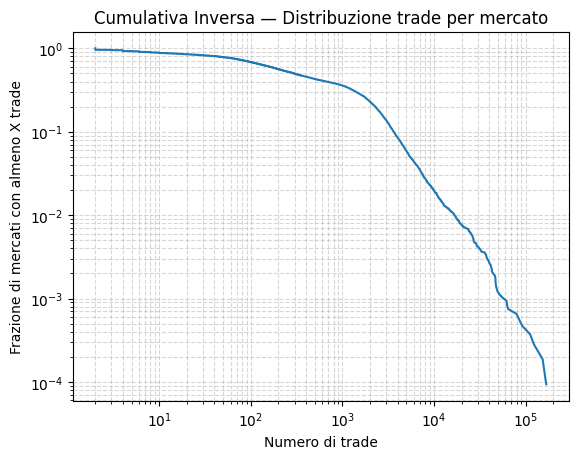

Mercati unici: 10,693

Trade Mediana per mercato: 296
Trade Media per mercato: 1577.0
Media > Mediana: pochi mercati dominano i trade

Mercato più attivo: 168,412 trade


In [8]:
# Conta i trade per mercato
trades_per_market = df.groupby('market_id').size()

# Ordinamento decrescente
sorted_counts = np.sort(trades_per_market.values)[::-1]

ccdf_x = sorted_counts
ccdf_y = np.arange(1, len(sorted_counts) + 1) / len(sorted_counts)

# Grafico
fig, ax = plt.subplots()
ax.plot(ccdf_x, ccdf_y)
# Rappresentazione logaritmica per entrambi gli assi
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_title('Cumulativa Inversa — Distribuzione trade per mercato')
ax.set_xlabel('Numero di trade')
ax.set_ylabel('Frazione di mercati con almeno X trade')
ax.grid(True, which='both', linestyle='--', alpha=0.5)    # per mostrare la griglia tratteggiata con sia le linee principali che secondarie
plt.show()

# Mostra le statistiche
print(f'Mercati unici: {len(trades_per_market):,}')
print()
print(f'Trade Mediana per mercato: {trades_per_market.median():.0f}')
print(f'Trade Media per mercato: {trades_per_market.mean():.1f}')
print(f'Media > Mediana: pochi mercati dominano i trade')
print()
print(f'Mercato più attivo: {trades_per_market.max():,} trade')

---
## Analisi - Distribuzione trade per wallet
### Cumulativa inversa

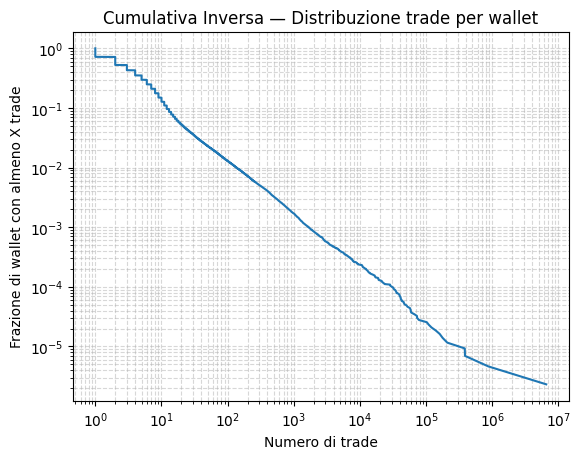

Wallet unici: 430,851

Trade Mediana per wallet: 3
Trade Media per wallet: 39.1
Media > Mediana: pochi wallet dominano i trade


In [9]:
# Conta i trade per wallet
trades_per_user = df.groupby('taker').size()

# Ordinamento decrescente
sorted_counts_user = np.sort(trades_per_user.values)[::-1]

ccdf_x_user = sorted_counts_user
ccdf_y_user = np.arange(1, len(sorted_counts_user) + 1) / len(sorted_counts_user)

# Grafico
fig, ax = plt.subplots()
ax.plot(ccdf_x_user, ccdf_y_user)

# Rappresentazione logaritmica per entrambi gli assi
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_title('Cumulativa Inversa — Distribuzione trade per wallet')
ax.set_xlabel('Numero di trade')
ax.set_ylabel('Frazione di wallet con almeno X trade')
ax.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

# Mostra le statistiche
print(f'Wallet unici: {len(trades_per_user):,}')
print()
print(f'Trade Mediana per wallet: {trades_per_user.median():.0f}')
print(f'Trade Media per wallet: {trades_per_user.mean():.1f}')
print(f'Media > Mediana: pochi wallet dominano i trade')

---
## Analisi - Top 3 mercati per numero di trade
### Istogramma

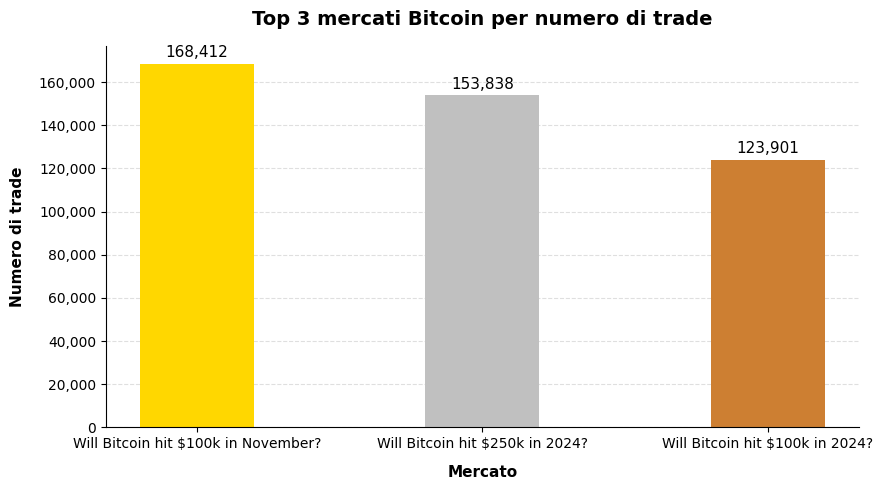

In [4]:
# Carico solo l'id ed il question da markets_btc.csv, così da associare la domanda al relativo market_id
markets = pd.read_csv('../output_btc/markets_btc.csv', usecols=['id', 'question'], dtype={'id': 'int32'})
markets = markets.drop_duplicates('id').set_index('id')

# Seleziona i top 3 mercati per numero di trade
top3 = df.groupby('market_id').size().nlargest(3).reset_index(name='n_trades')
top3['question'] = top3['market_id'].map(markets['question'])

# Grafico
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(top3['question'], top3['n_trades'], color=['#FFD700', '#C0C0C0', '#CD7F32'], width=0.4)
# Ho utilizzato i colori oro, argento e bronzo per rappresentare il podio dei mercati

# Mostra il valore specifico sopra ogni colonna
for bar, val in zip(bars, top3['n_trades']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + top3['n_trades'].max() * 0.01, f'{val:,}', ha='center', va='bottom', fontsize=11)

ax.set_title('Top 3 mercati Bitcoin per numero di trade', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Mercato', fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel('Numero di trade', fontsize=11, fontweight='bold', labelpad=10)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))    # Separatore per le migliaia sull'asse Y
ax.spines[['top', 'right']].set_visible(False)    # Rimuove il bordo sopra e a destra
ax.yaxis.grid(True, linestyle='--', alpha=0.4)   # Inserisce la griglia orizzontale tratteggiata semi-trasparente
ax.set_axisbelow(True)     # Definisce la griglia dietro le barre

plt.tight_layout()
plt.show()

---
## Analisi - Top 3 utenti per numero di trade
### Istogramma

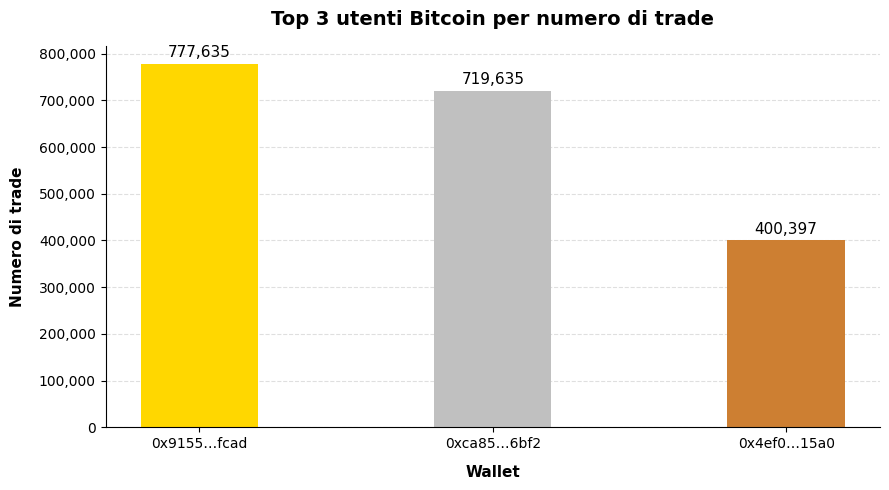

Top 3 wallet completi:
  0x9155e8cf81a3fb557639d23d43f1528675bcfcad — 777,635 trade
  0xca85f4b9e472b542e1df039594eeaebb6d466bf2 — 719,635 trade
  0x4ef0194e8cfd5617972665826f402836ac5f15a0 — 400,397 trade


In [3]:
# Filtro contratti infrastrutturali
contratti_infrastrutturali = [
    '0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e',    # Polymarket CTF Exchange (V1)
    '0xc5d563a36ae78145c45a50134d48a1215220f80a',    # Polymarket NegRisk CTF Exchange (V1)
]

# Conta le occorrenze di ogni wallet come maker e taker
trades_maker = df['maker'].astype(str).str.lower()
trades_taker = df['taker'].astype(str).str.lower()
n_trades_per_wallet = (pd.concat([trades_maker, trades_taker]).value_counts().rename('n_trades'))

# Esclude i contratti infrastrutturali dal totale
n_trades_per_wallet = n_trades_per_wallet[~n_trades_per_wallet.index.isin(contratti_infrastrutturali)]

# Top 3 wallet per numero di trade
top3_users = (n_trades_per_wallet.nlargest(3).rename_axis('wallet').reset_index(name='n_trades'))

# Etichette abbreviate per i wallet
top3_users['label'] = top3_users['wallet'].apply(lambda w: f"{w[:6]}…{w[-4:]}")

# Grafico
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(top3_users['label'], top3_users['n_trades'], color=['#FFD700', '#C0C0C0', '#CD7F32'], width=0.4)

# Mostra il valore specifico sopra ogni colonna
for bar, val in zip(bars, top3_users['n_trades']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + top3_users['n_trades'].max() * 0.01, f'{val:,}', ha='center', va='bottom', fontsize=11)

ax.set_title('Top 3 utenti Bitcoin per numero di trade', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Wallet', fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel('Numero di trade', fontsize=11, fontweight='bold', labelpad=10)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))     # Separatore per le migliaia sull'asse Y
ax.spines[['top', 'right']].set_visible(False)          # Rimuove il bordo sopra e a destra
ax.yaxis.grid(True, linestyle='--', alpha=0.4)         # Inserisce la griglia orizzontale tratteggiata semi-trasparente
ax.set_axisbelow(True)            # Definisce la griglia dietro le barre

plt.tight_layout()
plt.show()

print("Top 3 wallet completi:")
for _, row in top3_users.iterrows():
    print(f"  {row['wallet']} — {row['n_trades']:,} trade")

---
## Analisi - Numero di trade vs Durata media di partecipazione per wallet
### Scatter plot

Calcolo la durata di partecipazione per coppia (wallet, mercato)..
Coppie (wallet, mercato) trovate: 1,929,019
Wallet distinti analizzati: 430,851


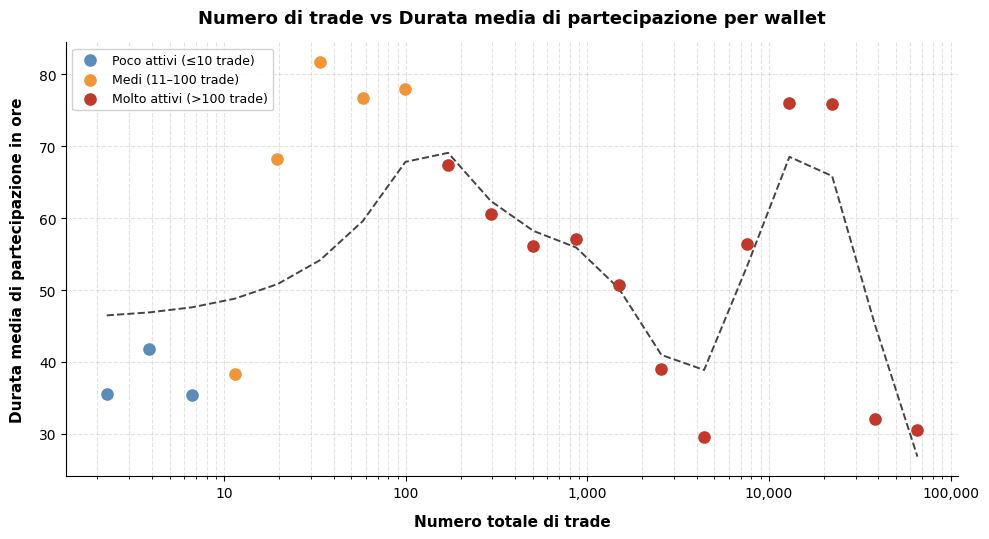


Durata media in base alla fascia di attività:
- Poco attivi (≤10) — 376,335 wallet — 25.47 ore
- Medi (11–100) — 48,975 wallet — 60.44 ore
- Molto attivi (>100) — 5,541 wallet — 63.22 ore


In [25]:
# Calcola la durata di partecipazione per coppia (wallet, mercato)
print('Calcolo la durata di partecipazione per coppia (wallet, mercato)..')

# Rimuove le righe in cui manca il timestamp
df_scatter = df.dropna(subset=['timestamp'])

# Raggruppa per coppia (wallet, mercato) e seleziona la colonna timestamp
grouped = df_scatter.groupby(['taker', 'market_id'], observed=True)['timestamp']

# Costruisce un DataFrame che contiene il numero di trade, il primo ed ultimo timestamp per ogni coppia
wallet_market = pd.DataFrame({
    'n_trades': grouped.count(),
    'first_ts': grouped.min(),
    'last_ts': grouped.max(),
}).reset_index()

# Calcola l'intervallo temporale tra il primo e l'ultimo trade del wallet in quel mercato
wallet_market['duration_sec'] = (wallet_market['last_ts'] - wallet_market['first_ts']).dt.total_seconds()
print(f'Coppie (wallet, mercato) trovate: {len(wallet_market):,}')

# Aggregazione per wallet, sommando i trade totali e calcolando la durata media su tutti i mercati per ogni wallet
wallet_stats = (wallet_market.groupby('taker', observed=True).agg(total_trades = ('n_trades','sum'), avg_duration = ('duration_sec','mean')).reset_index())
print(f'Wallet distinti analizzati: {len(wallet_stats):,}')

# Binning logaritmico: raggruppa i wallet in fasce logaritmiche(30) in base al numero di trade
bins = np.logspace(np.log10(max(wallet_stats['total_trades'].min(), 1)), np.log10(wallet_stats['total_trades'].max()), num=30)
wallet_stats['bin'] = pd.cut(wallet_stats['total_trades'], bins=bins)

# Calcola la durata media di partecipazione ed il numero di wallet per ogni bin
bin_stats = (wallet_stats.groupby('bin', observed=True)['avg_duration'].agg(mean='mean', count='count').reset_index())

# Calcola il centro del bin (punto nel grafico) come media geometrica tra il suo valore minimo e massimo
bin_stats['bin_center'] = bin_stats['bin'].apply(lambda b: np.sqrt(b.left * b.right))

# Esclude i bin con meno di 5 wallet, così da evitare i punti meno rilevanti
bin_stats_plot = bin_stats[bin_stats['count'] >= 5].dropna(subset=['bin_center'])

# Converte la durata media di partecipazione da secondi in ore
bin_stats_plot = bin_stats_plot.copy()
bin_stats_plot['mean_h'] = bin_stats_plot['mean'] / 3600

# Converte bin_center in float, altrimenti la funzione pd.cut assegnerebbe automaticamente il tipo category, causando un errore di tipo
bin_stats_plot['bin_center'] = bin_stats_plot['bin_center'].astype(float)

# Definisce il colore dei punti in base alla fascia di attività del wallet
def get_color(x):
    if x <= 10:
        return '#5B8DB8'    # blu per i wallet poco attivi
    elif x <= 100:
        return '#F0953A'    # arancione per i wallet medi
    else:
        return '#C0392B'    # rosso per i wallet molto attivi

# Calcola la trend line, così da evidenziare l'andamento generale
x_lowess = bin_stats_plot['bin_center']
y_lowess = bin_stats_plot['mean_h']
# Nel calcolo della curva utilizza il 50% dei punti vicini per ogni calcolo locale
smoothed = lowess(y_lowess, x_lowess, frac=0.5, return_sorted=True)

# Grafico
fig, ax = plt.subplots(figsize=(10, 5.5))
x = bin_stats_plot['bin_center']
# Definisce i punti in base alla fascia, così da poterli colorare ed etichettare nella legenda
for label, color, mask in [
    ('Poco attivi (≤10 trade)', '#5B8DB8', x <= 10),
    ('Medi (11–100 trade)', '#F0953A', (x > 10) & (x <= 100)),
    ('Molto attivi (>100 trade)', '#C0392B', x > 100),
]:
    subset = bin_stats_plot[mask]
    ax.scatter(subset['bin_center'], subset['mean_h'], color=color, s=65, zorder=3, label=label)

# Mostra la trend line sul grafico
ax.plot(smoothed[:, 0], smoothed[:, 1], color='#444444', linewidth=1.4, linestyle='--', zorder=2, label='_Trend line')

# Imposta l'asse X in scala logaritmica
ax.set_xscale('log')
ax.set_title('Numero di trade vs Durata media di partecipazione per wallet', fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Numero totale di trade', fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel('Durata media di partecipazione in ore', fontsize=11, fontweight='bold', labelpad=10)

# Formatta l'asse X con il separatore delle migliaia e l'asse Y con numeri interi
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}'))

# Aggiunge la legenda in alto a sinistra
ax.legend(fontsize=9, loc='upper left', framealpha=0.9)
# Inserisce la griglia tratteggiata su entrambi gli assi
ax.grid(True, which='both', linestyle='--', alpha=0.35)
# Rimuove i bordi superiore e destro del grafico
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# Riepilogo delle statistiche: dividendo i wallet nelle tre fasce di attività
low = wallet_stats[wallet_stats['total_trades'] <= 10]
medium = wallet_stats[(wallet_stats['total_trades'] > 10) & (wallet_stats['total_trades'] <= 100)]
high = wallet_stats[wallet_stats['total_trades'] > 100]

print('\nDurata media in base alla fascia di attività:')
print(f"- Poco attivi (≤10) — {len(low):,} wallet — {low['avg_duration'].mean()/3600:.2f} ore")
print(f"- Medi (11–100) — {len(medium):,} wallet — {medium['avg_duration'].mean()/3600:.2f} ore")
print(f"- Molto attivi (>100) — {len(high):,} wallet — {high['avg_duration'].mean()/3600:.2f} ore")

---
## Analisi - Andamento del volume dei trade nei mercati Bitcoin
### Time series

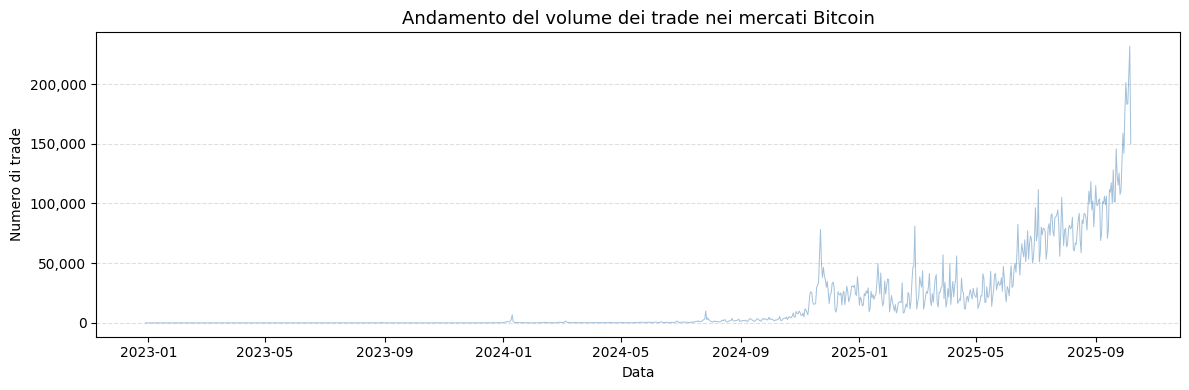

Periodo: 2022-12-29 -> 2025-10-07
Media giornaliera: 16,630 trade/giorno
Picco massimo: 231,718 trade il 2025-10-06


In [26]:
# Imposta il timestamp come indice, raggruppa i trade per giorno e conta quanti trade sono avvenuti ogni giorno
daily_trades = (df.set_index('timestamp').resample('D')['market_id'].count().rename('n_trades'))

# Grafico
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily_trades.index, daily_trades.values, color='steelblue', linewidth=0.7, alpha=0.5)   # Mostra la serie dei trade giornalieri

ax.set_title('Andamento del volume dei trade nei mercati Bitcoin', fontsize=13)
ax.set_xlabel('Data')
ax.set_ylabel('Numero di trade')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))   # Separatore per le migliaia sull'asse Y
ax.grid(axis='y', linestyle='--', alpha=0.4)    # Griglia orizzontale tratteggiata semi-trasparente

plt.tight_layout()
plt.show()

# Mostra le statistiche della serie temporale
print(f"Periodo: {daily_trades.index.min().date()} -> {daily_trades.index.max().date()}")    # espressi nella notazione classica: anno-mese-giorno
print(f"Media giornaliera: {daily_trades.mean():,.0f} trade/giorno")
print(f"Picco massimo: {daily_trades.max():,} trade il {daily_trades.idxmax().date()}")

### Focus: andamento volume dei trade - fine 2024/2025

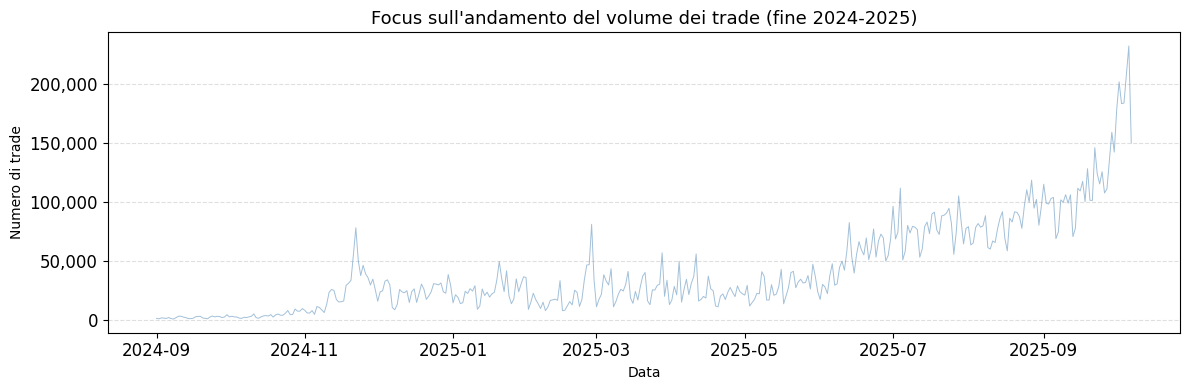

In [27]:
# Filtra dalla fine del 2024 in poi
daily_trades_zoom = daily_trades[daily_trades.index >= '2024-09-01']

# Grafico
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily_trades_zoom.index, daily_trades_zoom.values, color='steelblue', linewidth=0.7, alpha=0.5)

ax.set_title("Focus sull'andamento del volume dei trade (fine 2024-2025)", fontsize=13)
ax.set_xlabel('Data')
ax.set_ylabel('Numero di trade')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Aumenta la dimensione delle etichette degli assi per migliorare la leggibilità
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

plt.tight_layout()
plt.show()

## Analisi correlata - Crescita dei nuovi wallet sulla piattaforma
### Time series

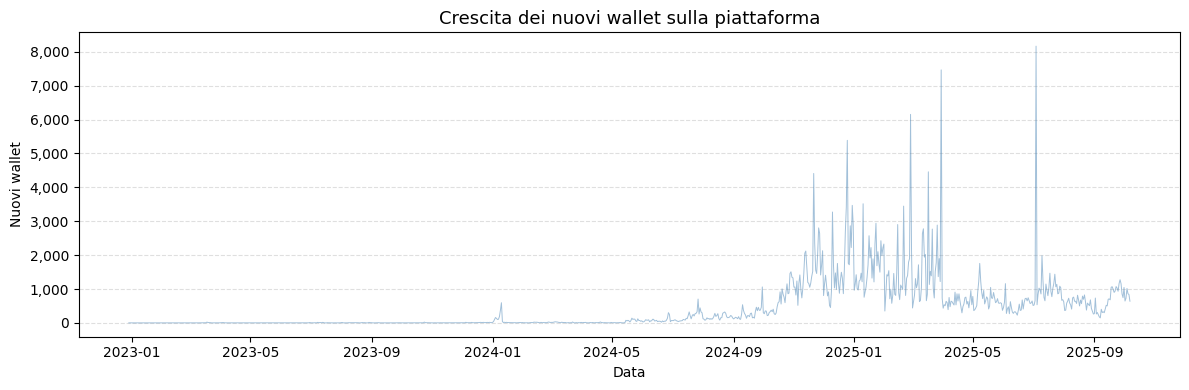

Totale nuovi wallet: 430,851
Media giornaliera: 514 nuovi wallet/giorno
Picco massimo: 8,167 nuovi wallet il 2025-07-04


In [28]:
# Per ogni wallet, ricavare la data del primo trade effettuato
first_trade = df.groupby('taker')['timestamp'].min()

# Raggruppa per giorno e conta quanti wallet hanno fatto il loro primo trade in quel giorno
new_users_daily = (first_trade.dt.floor('D').value_counts().sort_index().rename('new_users'))

# Grafico
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(new_users_daily.index, new_users_daily.values, color='steelblue', linewidth=0.7, alpha=0.5)

ax.set_title('Crescita dei nuovi wallet sulla piattaforma', fontsize=13)
ax.set_xlabel('Data')
ax.set_ylabel('Nuovi wallet')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))   # Separatore per le migliaia sull'asse Y
ax.grid(axis='y', linestyle='--', alpha=0.4)    # Griglia orizzontale tratteggiata semi-trasparente

plt.tight_layout()
plt.show()

# Mostra le statistiche dei nuovi wallet
print(f"Totale nuovi wallet: {new_users_daily.sum():,}")
print(f"Media giornaliera: {new_users_daily.mean():,.0f} nuovi wallet/giorno")
print(f"Picco massimo: {new_users_daily.max():,} nuovi wallet il {new_users_daily.idxmax().date()}")

### Focus: andamento nuovi wallet - fine 2024/2025

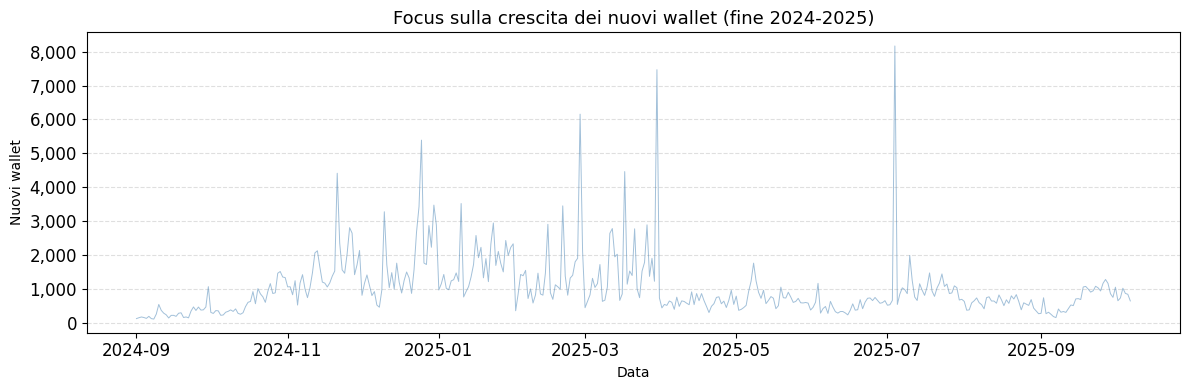

In [29]:
# Filtra dalla fine del 2024 in poi
new_users_2024 = new_users_daily[new_users_daily.index >= '2024-09-01']

# Grafico
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(new_users_2024.index, new_users_2024.values, color='steelblue', linewidth=0.7, alpha=0.5)

ax.set_title("Focus sulla crescita dei nuovi wallet (fine 2024-2025)", fontsize=13)
ax.set_xlabel('Data')
ax.set_ylabel('Nuovi wallet')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Aumenta la dimensione delle etichette degli assi per migliorare la leggibilità
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

plt.tight_layout()
plt.show()

## Analisi correlata - Relazione tra attività di trading e crescita dei nuovi wallet
### Time series

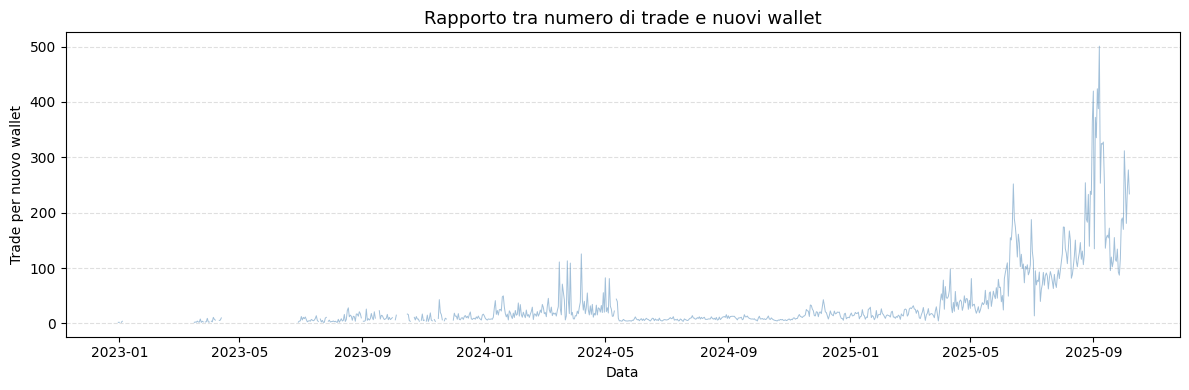

Picco massimo: 500.6 trade/wallet il 2025-09-07
Giorni esclusi (0 nuovi utenti): 175 su 1014


In [30]:
# Allinea le due serie sullo stesso indice temporale, riempiendo con 0 i giorni mancanti
daily_trades_aligned, new_users_aligned = daily_trades.align(new_users_daily, fill_value=0)

# Calcola il rapporto trade/nuoviwallet per ogni giorno, evitando divisioni per zero, 
# infatti se new_users_aligned è 0, il rapporto diventa NaN
ratio = (daily_trades_aligned / new_users_aligned.replace(0, np.nan)).rename('trade_per_nuovo_wallet')

# Grafico
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ratio.index, ratio.values, color='steelblue', linewidth=0.7, alpha=0.5)

ax.set_title('Rapporto tra numero di trade e nuovi wallet', fontsize=13)
ax.set_xlabel('Data')
ax.set_ylabel('Trade per nuovo wallet')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# Mostra le statistiche del rapporto
print(f"Picco massimo: {ratio.dropna().max():,.1f} trade/wallet il {ratio.dropna().idxmax().date()}")
print(f"Giorni esclusi (0 nuovi utenti): {new_users_aligned.eq(0).sum()} su {len(new_users_aligned)}")

---
## Analisi - Evoluzione temporale dei trade nei Top 3 mercati Bitcoin
### Time series

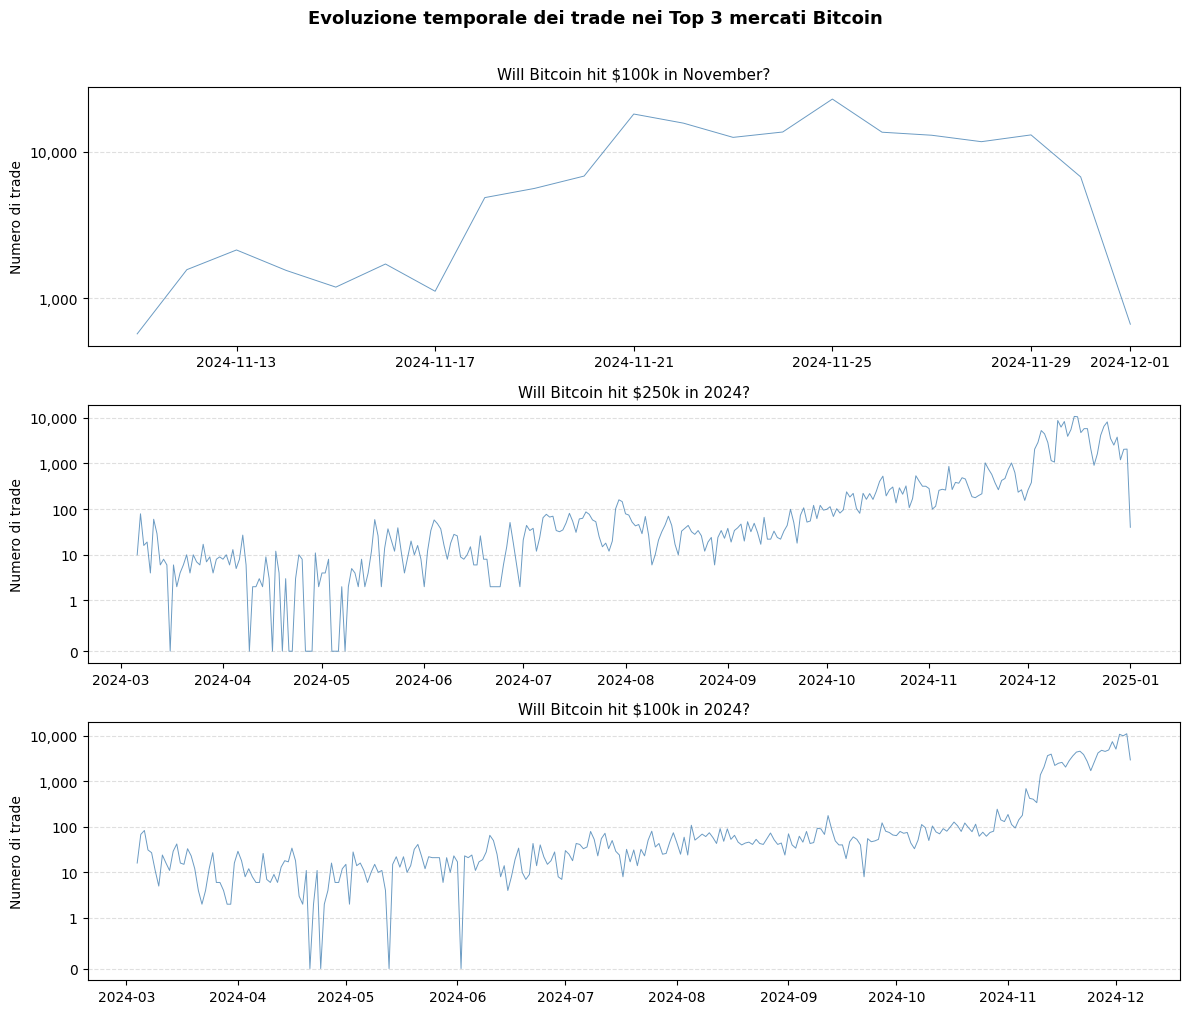

In [6]:
# Utilizzo il risultato calcolato precedentemente per ottenere i top 3 mercati
top3_ids = top3['market_id'].tolist()

# Grafico
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Per ognuno dei 3 mercati, crea il relativo grafico
for i, mid in enumerate(top3_ids):
    # Filtra i trade del mercato corrente, li raggruppa in base al giorno e li conta
    subset = df[df['market_id'] == mid].set_index('timestamp').resample('D')['market_id'].count().rename('n_trades')
    
    # Ottiene la domanda del mercato, che utilizzo come titolo del grafico
    question = markets.loc[mid, 'question']
    
    # Mostra la serie giornaliera dei trade
    axes[i].plot(subset.index, subset.values, color='steelblue', linewidth=0.7, alpha=0.8)
    
    axes[i].set_title(question, fontsize=11)
    axes[i].set_ylabel('Numero di trade')
    axes[i].set_yscale('symlog', linthresh=1)   # Scala logaritmica, che mostra sia i picchi che i periodi di inattività
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))    # Separatore per le migliaia sull'asse Y
    axes[i].grid(axis='y', linestyle='--', alpha=0.4)    # Griglia orizzontale tratteggiata semi-trasparente

plt.suptitle('Evoluzione temporale dei trade nei Top 3 mercati Bitcoin', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Analisi correlata - Verifica del pattern temporale su tutti i mercati Bitcoin
### Istogramma normalizzato

Mercati analizzati: 8,829

Frazione media per chunk:
[0.0418 0.0249 0.0315 0.0376 0.048  0.0667 0.0852 0.119  0.2015 0.3438]

Top 1 - market_id 512600:
[0.0215 0.0174 0.0169 0.0461 0.1099 0.1845 0.1726 0.1813 0.144  0.1058]
Top 2 - market_id 255322:
[0.0025 0.0009 0.0028 0.0034 0.0113 0.0059 0.0108 0.0456 0.0791 0.8378]
Top 3 - market_id 255229:
[0.0045 0.0024 0.0033 0.0045 0.0069 0.0116 0.0129 0.0132 0.0302 0.9106]


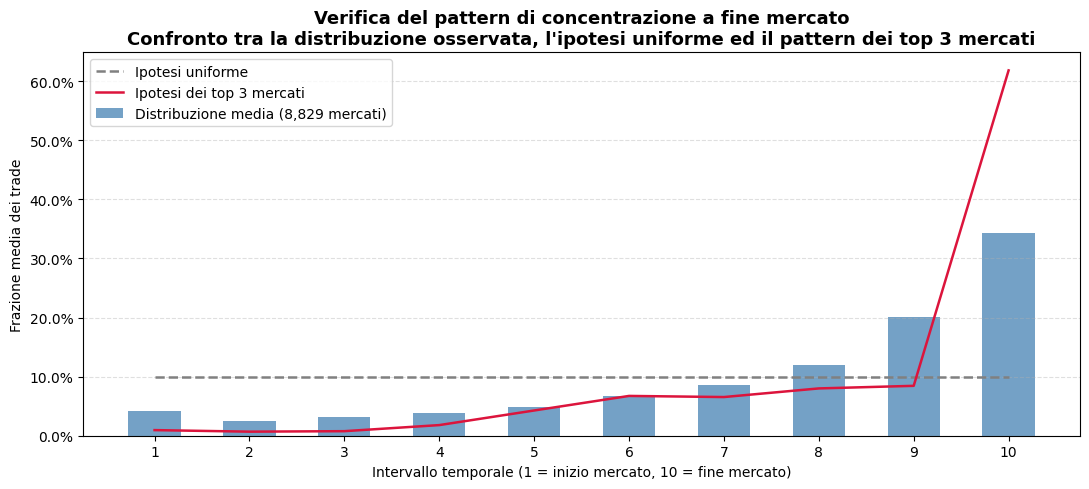

In [32]:
# Verifica se la concentrazione dei trade a fine mercato, evidenziata dalle time series dei top 3 mercati Bitcoin, si estende a tutti i mercati Bitcoin

# Per ogni mercato si normalizza la sua durata in 10 chunk temporali ed in ogni chunk si conta la frazione dei trade rispetto al totale del mercato
# Poi si fa la media di queste frazioni su tutti i mercati e si confronta con:
# - Ipotesi uniforme: i trade vengono distribuiti in modo uniforme nelle partizioni
# - Ipotesi top 3: verifica la concentrazione dei trade a fine mercato riscontrata nei top 3 mercati

# Utilizzo il risultato calcolato precedentemente per ottenere i top 3 mercati

N_CHUNKS = 10     # numero di partizioni temporali
MIN_TRADES = 30    # i mercati con meno trade vengono esclusi

# Per ogni mercato calcola la distribuzione nei 10 chunk
records = []    # ogni elemento sarà un array di N_CHUNKS frazioni

for mid, group in df.groupby('market_id'):
    ts = group['timestamp'].dropna().sort_values()
    n_total = len(ts)

    # Scarta i mercati con pochi trade
    if n_total < MIN_TRADES:
        continue

    t_min = ts.iloc[0]
    t_max = ts.iloc[-1]
    durata = (t_max - t_min).total_seconds()

    # Scarta i mercati in cui tutti i trade avvengono nello stesso istante
    if durata == 0:
        continue

    # Calcola a quale chunk appartiene ogni trade ed il clip riporta l'ultimo timestamp nel chunk 9, ultimo chunk valido e non nel 10
    offsets = (ts - t_min).dt.total_seconds()
    chunk_idx = ((offsets / durata) * N_CHUNKS).clip(upper=N_CHUNKS - 1).astype(int)

    # Conta i trade per chunk e divide per il totale del mercato per ottenere le relative frazioni
    counts = np.bincount(chunk_idx, minlength=N_CHUNKS).astype(float)
    fractions = counts / n_total

    records.append(fractions)

# Converte la lista in una matrice (n_mercati × N_CHUNKS) per calcolare direttamente la media di ogni chunk tra tutti i mercati
matrix = np.array(records)
mean_fractions = matrix.mean(axis=0)

print(f'Mercati analizzati: {len(records):,}')
print()
print(f'Frazione media per chunk:\n{np.round(mean_fractions, 4)}')
print()

# Definisce le due ipotesi:

# Ipotesi uniforme: i trade vengono distribuiti in modo uniforme nelle partizioni
uniform = np.full(N_CHUNKS, 1.0 / N_CHUNKS)

# Ipotesi top 3: distribuzione calcolata dai dati dei top 3 mercati, che mostrano una concentrazione dei trade a fine mercato
top3_ids = top3['market_id'].tolist()
records_top3 = []

for mid in top3_ids:
    ts = df[df['market_id'] == mid]['timestamp'].dropna().sort_values()
    n_total = len(ts)
    t_min, t_max = ts.iloc[0], ts.iloc[-1]
    durata = (t_max - t_min).total_seconds()
    if durata == 0:
        continue
    offsets = (ts - t_min).dt.total_seconds()
    chunk_idx = ((offsets / durata) * N_CHUNKS).clip(upper=N_CHUNKS - 1).astype(int)
    counts = np.bincount(chunk_idx, minlength=N_CHUNKS).astype(float)
    records_top3.append(counts / n_total)

# Calcola e stampa la distribuzione per chunk di ogni mercato nella top 3
for i, (mid, fracs) in enumerate(zip(top3_ids, records_top3)):
    print(f'Top {i+1} - market_id {mid}:')
    print(np.round(fracs, 4))

hypothesis_top3 = np.array(records_top3).mean(axis=0)    # media tra i top 3 mercati per ogni chunk

# Grafico
chunk_labels = []         # etichette degli intervalli temporali, da 1 (inizio mercato) a 10 (fine mercato)
for i in range(N_CHUNKS):
    chunk_labels.append(str(i + 1))
x = np.arange(N_CHUNKS)
bar_width = 0.55

fig, ax = plt.subplots(figsize=(11, 5))

# Le barre rappresentano la distribuzione media su tutti i mercati Bitcoin
ax.bar(x, mean_fractions, width=bar_width, color='steelblue', alpha=0.75, label=f'Distribuzione media ({len(records):,} mercati)')

# La linea tratteggiata rappresenta l'ipotesi uniforme
ax.plot(x, uniform, color='gray', linewidth=1.8, linestyle='--', label='Ipotesi uniforme')

# La linea continua rappresenta l'ipotesi dei top 3 mercati
ax.plot(x, hypothesis_top3, color='crimson', linewidth=1.8, linestyle='-', label='Ipotesi dei top 3 mercati')

ax.set_xlabel('Intervallo temporale (1 = inizio mercato, 10 = fine mercato)')
ax.set_ylabel('Frazione media dei trade')
ax.set_title('Verifica del pattern di concentrazione a fine mercato\n'
             "Confronto tra la distribuzione osservata, l'ipotesi uniforme ed il pattern dei top 3 mercati", fontsize=13, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(chunk_labels)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.1%}'))    # asse Y in percentuale
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

---
## Analisi - Distribuzione dei trade per fascia oraria
### Istogramma

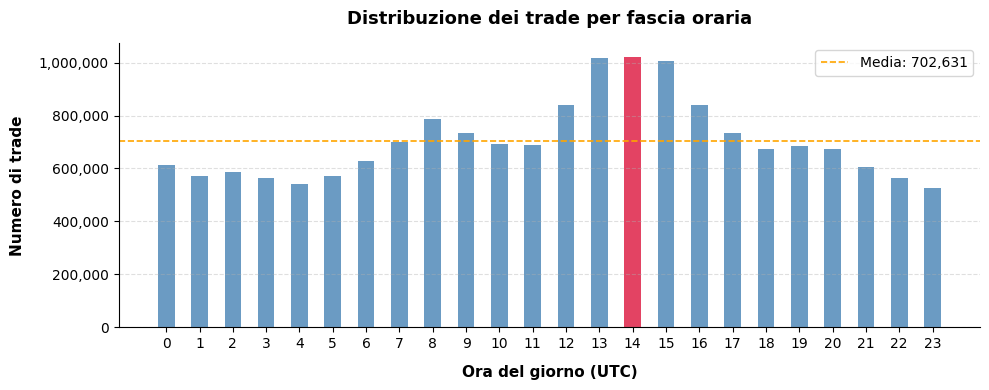

Ora più attiva: 14:00 — 1,021,150 trade
Ora meno attiva: 23:00 — 526,392 trade


In [33]:
# Estrae l'ora del giorno da ogni timestamp e conta il numero di trade per ogni fascia oraria
hourly = df['timestamp'].dt.hour.value_counts().sort_index().rename('n_trades')

# Grafico
fig, ax = plt.subplots(figsize=(10, 4))
# Evidenzia in rosso la barra dell'ora più attiva e le altre in blu
colors = ['crimson' if h == hourly.idxmax() else 'steelblue' for h in hourly.index]
ax.bar(hourly.index, hourly.values, color=colors, alpha=0.8, width=0.5)

# Inserisce una linea orizzontale tratteggiata che mostra la media oraria
ax.axhline(hourly.mean(), color='orange', linestyle='--', linewidth=1.2, label=f'Media: {hourly.mean():,.0f}')
ax.legend()

ax.set_title('Distribuzione dei trade per fascia oraria', fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Ora del giorno (UTC)', fontsize=11, fontweight='bold', labelpad=10)
# Gli orari mostrati sono in UTC, senza effettuare conversioni in base al fuso orario
ax.set_ylabel('Numero di trade', fontsize=11, fontweight='bold', labelpad=10)

ax.set_xticks(range(24))     # Mostra tutte le 24 ore sull'asse X
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))    # Separatore per le migliaia sull'asse Y
ax.grid(axis='y', linestyle='--', alpha=0.4)    # Griglia orizzontale tratteggiata semi-trasparente
ax.spines[['top', 'right']].set_visible(False)     # Rimuove il bordo superiore e destro

plt.tight_layout()
plt.show()

# Mostra le statistiche
print(f"Ora più attiva: {hourly.idxmax()}:00 — {hourly.max():,} trade")
print(f"Ora meno attiva: {hourly.idxmin()}:00 — {hourly.min():,} trade")

---
## Analisi - Coefficiente di Gini per mercato e wallet

In [4]:
# Funzione per il calcolo del coefficiente di Gini
def CoefGini(arr):
    arr = np.sort(arr)       # Ordina i valori in modo crescente
    n = len(arr)
    index = np.arange(1, n + 1)   # Indici da 1 ad n
    return (2 * (index * arr).sum()) / (n * arr.sum()) - (n + 1) / n

# Conta il numero di trade per mercato e per wallet
trades_per_market = df.groupby('market_id').size().values
trades_per_wallet = df.groupby('taker').size().values

# Calcolo del coefficiente di Gini per mercato e per wallet
print('Calcolo del coefficiente di Gini per mercato..')
gini_market = CoefGini(trades_per_market)
print(f'Coefficiente di Gini: {gini_market:.4f} (calcolato su {len(trades_per_market)} mercati)')
print()
print('Calcolo del coefficiente di Gini per wallet..')
gini_wallet = CoefGini(trades_per_wallet)
print(f'Coefficiente di Gini: {gini_wallet:.4f} (calcolato su {len(trades_per_wallet)} wallet)')

Calcolo del coefficiente di Gini per mercato..
Coefficiente di Gini: 0.7515 (calcolato su 10693 mercati)

Calcolo del coefficiente di Gini per wallet..
Coefficiente di Gini: 0.9366 (calcolato su 430851 wallet)


### Rappresentazione grafica

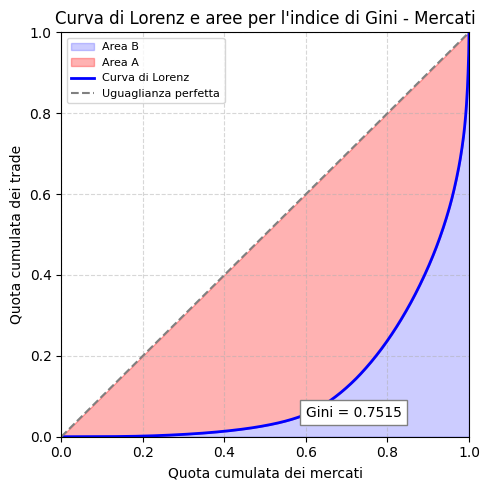

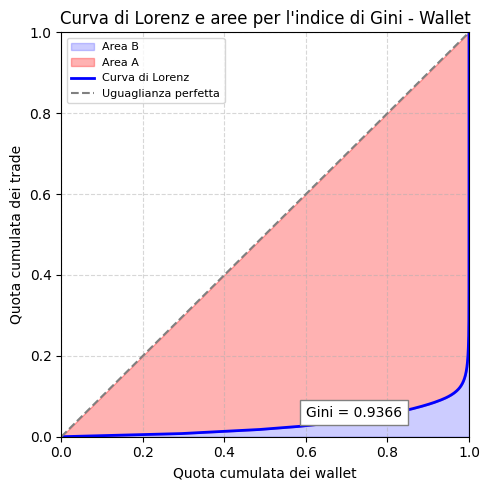

In [5]:
# Funzione per calcolare le coordinate della curva di Lorenz
def LorenzCurve(arr):
    arr = np.sort(arr)              # Ordina i valori in modo crescente
    cum_arr = np.cumsum(arr) / arr.sum()       # Calcola la frazione cumulata dei trade
    cum_arr = np.insert(cum_arr, 0, 0)         # Aggiunge il punto di partenza (0,0)
    cum_pop = np.linspace(0, 1, len(cum_arr))    # Frazione cumulata generale
    return cum_pop, cum_arr

# Funzione per disegnare il grafico della curva di Lorenz
def PlotLorenz(arr, gini, titolo, entita):
    cum_pop, cum_arr = LorenzCurve(arr)         # Calcola le coordinate della curva
    fig, ax = plt.subplots(figsize=(5, 5))
    
    # Area B, sotto la curva di Lorenz, frazione di trade effettivamente distribuita
    ax.fill_between(cum_pop, cum_arr, 0, color='blue', alpha=0.2, label='Area B')
    # Area A, tra la retta di uguaglianza perfetta e la curva di Lorenz, disuguaglianza
    ax.fill_between(cum_pop, cum_pop, cum_arr, color='red', alpha=0.3, label='Area A')
    
    # Curva di Lorenz
    ax.plot(cum_pop, cum_arr, color='blue', linewidth=2, label='Curva di Lorenz')
    
    # Retta di uguaglianza perfetta, bisettrice
    ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Uguaglianza perfetta')
    
    ax.set_title(f'Curva di Lorenz e aree per l\'indice di Gini - {titolo}', fontsize=12)
    ax.set_xlabel(f'Quota cumulata dei {entita}', fontsize=10)
    ax.set_ylabel('Quota cumulata dei trade', fontsize=10)
    ax.legend(loc='upper left', fontsize=8)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle='--', alpha=0.5)
    # Etichetta con il valore del coefficiente di Gini calcolato
    ax.text(0.6, 0.05, f'Gini = {gini:.4f}', fontsize=10, bbox=dict(facecolor='white', edgecolor='gray'))
    
    plt.tight_layout()
    plt.show()

# Grafico per i mercati
PlotLorenz(trades_per_market, gini_market, 'Mercati', 'mercati')

# Grafico per i wallet
PlotLorenz(trades_per_wallet, gini_wallet, 'Wallet', 'wallet')

---
## Analisi - Andamento dei trade nel tempo per i Top 3 utenti Bitcoin
### Time series

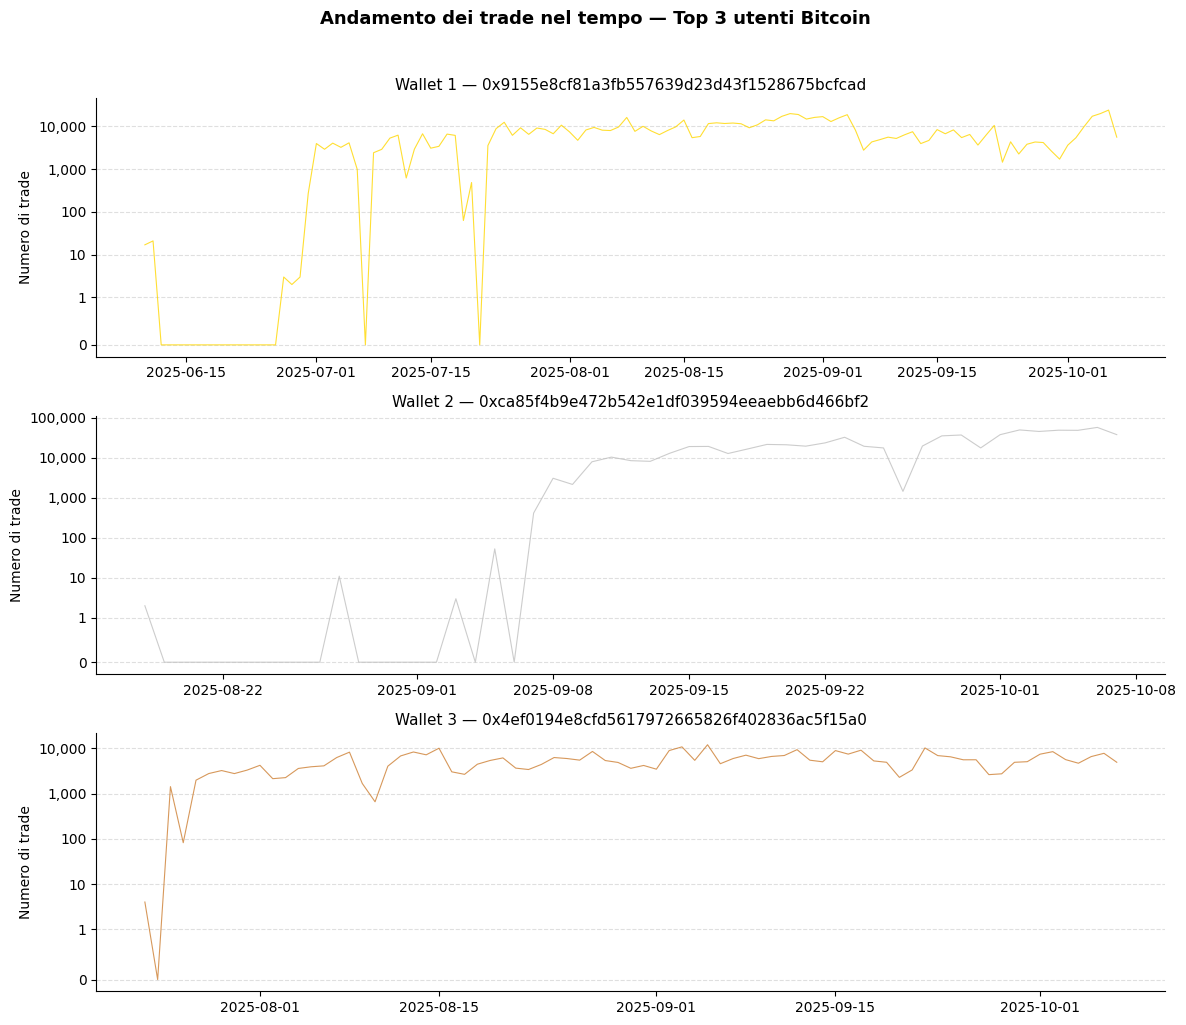

Statistiche per i top 3 wallet:

Top 1 — 0x9155e8cf81a3fb557639d23d43f1528675bcfcad
Periodo attivo: 2025-06-10 -> 2025-10-07
Giorni attivi: 103
Media giornaliera (giorni attivi): 7,549.9 trade/giorno
Picco massimo: 24,209 trade il 2025-10-06

Top 2 — 0xca85f4b9e472b542e1df039594eeaebb6d466bf2
Periodo attivo: 2025-08-18 -> 2025-10-07
Giorni attivi: 35
Media giornaliera (giorni attivi): 20,561.0 trade/giorno
Picco massimo: 57,963 trade il 2025-10-06

Top 3 — 0x4ef0194e8cfd5617972665826f402836ac5f15a0
Periodo attivo: 2025-07-23 -> 2025-10-07
Giorni attivi: 76
Media giornaliera (giorni attivi): 5,268.4 trade/giorno
Picco massimo: 11,997 trade il 2025-09-05



In [13]:
# Ottiene i wallet dei top 3 utenti, calcolati nell'analisi precedente
top3_wallets = set(top3_users['wallet'].str.lower())

# Filtra il dataset tenendo solo i trade dei top 3 utenti
df_top3 = df[df['maker'].str.lower().isin(top3_wallets) | df['taker'].str.lower().isin(top3_wallets)].copy()

# Calcola la time series giornaliera per ognuno dei 3 wallet
# infatti, per ogni wallet, imposta il timestamp come indice, raggruppa per giorno e conta i trade
daily_by_user = {}
for _, row in top3_users.iterrows():
    wallet = row['wallet']
    label = row['label']
    mask_maker = df_top3['maker'].str.lower() == wallet.lower()
    mask_taker = df_top3['taker'].str.lower() == wallet.lower()
    series_maker = df_top3[mask_maker].set_index('timestamp').resample('D')['market_id'].count()
    series_taker = df_top3[mask_taker].set_index('timestamp').resample('D')['market_id'].count()
    series = series_maker.add(series_taker, fill_value=0).rename(label)
    daily_by_user[label] = series

# Utilizzo i 3 colori (oro, argento e bronzo) per i 3 wallet, come nel grafico precedente
colors = ['#FFD700', '#C0C0C0', '#CD7F32']

# Grafico
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

for i, ((label, series), (_, row)) in enumerate(zip(daily_by_user.items(), top3_users.iterrows())):
    # Mostra la serie dei trade
    axes[i].plot(series.index, series.values, color=colors[i], linewidth=0.8, alpha=0.8)
    axes[i].set_title(f'Wallet {i+1} — {row["wallet"]}', fontsize=11)
    axes[i].set_ylabel('Numero di trade')
    axes[i].set_yscale('symlog', linthresh=1)   # Scala logaritmica, che mostra sia i picchi che i periodi di inattività
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))    # Separatore per le migliaia sull'asse Y
    axes[i].grid(axis='y', linestyle='--', alpha=0.4)    # Griglia orizzontale tratteggiata semi-trasparente
    axes[i].spines[['top', 'right']].set_visible(False)

plt.suptitle('Andamento dei trade nel tempo — Top 3 utenti Bitcoin', fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

# Mostra le statistiche per ogni wallet
print("Statistiche per i top 3 wallet:\n")
for i, ((label, series), (_, row)) in enumerate(zip(daily_by_user.items(), top3_users.iterrows())):
    active_days = (series > 0).sum()    # giorni in cui il wallet ha fatto almeno un trade
    print(f"Top {i+1} — {row['wallet']}")
    print(f"Periodo attivo: {series[series > 0].index.min().date()} -> {series[series > 0].index.max().date()}")    # formato anno-mese-giorno
    print(f"Giorni attivi: {active_days:,}")
    print(f"Media giornaliera (giorni attivi): {series[series > 0].mean():,.1f} trade/giorno")
    print(f"Picco massimo: {series.max():,} trade il {series.idxmax().date()}\n")

---